# 🔧 LoRA Training (Stable Diffusion XL (SDXL)) — Google Colab

---



## Step 1 : Dependency Installation

In [1]:
!pip install \
  opencv-python \
  diffusers["torch"] \
  transformers \
  accelerate \
  safetensors \
  tensorboard \
  einops \
  torchaudio \
  xformers \
  bitsandbytes \
  prodigyopt \
  lion-pytorch \
  opencv-python \
  ftfy \
  easygui \
  toml \
  voluptuous \
  imagesize \
  peft

!pip install --force-reinstall --no-cache-dir \
  torch==2.9.1 \
  torchvision \
  torchaudio==2.9.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 164.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 174.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 141.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 36.7 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 49.4 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 161.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 100.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 46.2 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 128.7 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 99.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 148.1 MB/s  0:00:

In [1]:
# Dependency Check Here
# opencv-python Missing is OK Only for GUI

import importlib

libs_to_check = [
    # Hugging Face core
    "torch", "torchvision", "torchaudio",
    "transformers", "diffusers", "accelerate",

    # Memory/optimization
    "xformers", "bitsandbytes", "safetensors", "einops",

    # Training frameworks
    "pytorch_lightning", "prodigyopt", "lion_pytorch",

    # Data & preprocessing
    "opencv-python", "cv2", "PIL", "ftfy", "sentencepiece", "datasets",

    # Utils & viz
    "tensorboard", "huggingface_hub", "altair", "easygui",
    "toml", "voluptuous", "imagesize", "rich"
]

# special cases where version attribute differs
special_version_attrs = {
    "cv2": "version",
    "PIL": "PILLOW_VERSION",  # old
}

for lib in libs_to_check:
    try:
        module_name = lib.replace("-", "_")
        module = importlib.import_module(module_name)

        # try __version__, or special attributes, or unknown
        version = getattr(module, "__version__", None)
        if version is None:
            # handle cv2, PIL, etc.
            if lib in special_version_attrs:
                version = getattr(module, special_version_attrs[lib], None)
            elif lib == "PIL":
                try:
                    import PIL
                    version = getattr(PIL, "__version__", None)
                except Exception:
                    version = None

        print(f"✅ {lib} - {version if version else 'unknown'}")

    except Exception as e:
        print(f"❌ {lib} - MISSING ({e.__class__.__name__})")

✅ torch - 2.9.1+cu128
✅ torchvision - 0.24.1+cu128
✅ torchaudio - 2.9.1+cu128
✅ transformers - 4.57.1
✅ diffusers - 0.36.0
✅ accelerate - 1.11.0
✅ xformers - 0.0.33.post2
✅ bitsandbytes - 0.49.0
✅ safetensors - 0.6.2
✅ einops - 0.8.1
✅ pytorch_lightning - 2.5.5
✅ prodigyopt - unknown
✅ lion_pytorch - unknown
❌ opencv-python - MISSING (ModuleNotFoundError)
✅ cv2 - 4.12.0
✅ PIL - 12.1.0
✅ ftfy - 6.3.1
✅ sentencepiece - 0.2.0
✅ datasets - 2.2.1
✅ tensorboard - 2.18.0
✅ huggingface_hub - 0.36.0
✅ altair - 5.5.0
✅ easygui - unknown
✅ toml - 0.10.2
✅ voluptuous - 0.16.0
✅ imagesize - 1.4.1
✅ rich - unknown


## STEP 2 — Download Base Model

In [1]:
from huggingface_hub import snapshot_download, login

# 🔑 Login with your HuggingFace token (must have accepted SDXL license)
login("")
MODEL = "sdxl-base-1.0"
MODEL_DIR = f"./content/{MODEL}" # Set our Path to Drive If needed

# 📥 Download SDXL 1.0 base model from StabilityAI

snapshot_download(
    repo_id="stabilityai/stable-diffusion-xl-base-1.0",
    local_dir=MODEL_DIR,
    local_dir_use_symlinks=False,
    allow_patterns=[
        "*.safetensors",              # main weights
        "model_index.json",           # model config
        "tokenizer/*",
        "tokenizer/*", "tokenizer_2/*",   # << include both!
        "text_encoder/*", "text_encoder_2/*",# tokenizer files
        "scheduler/*",                # schedulers
        "vae/*",                      # VAE
        "unet/*",                     # UNet
        "text_encoder/*",             # text encoder
        "*.json",                     # other configs
    ]
)

print("✅ SDXL 1.0 Base download complete at /content/sdxl-base-1.0")

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 45 files:   0%|          | 0/45 [00:00<?, ?it/s]

✅ SDXL 1.0 Base download complete at /content/drive/MyDrive/SD/models/sdxl-base-1.0


## STEP 3 — Project Config

In this step, we set up the project details and training parameters:  

- **Project Name** — used to create folders for datasets, outputs, and logs.  
- **Trigger Word** — a unique token (e.g., `akashawriter`) that activates your LoRA.  
- **Paths** — dataset, images, outputs, and logs are auto-created in Google Drive.

In [2]:
# ==== USER CONFIG ====
PROJECT_NAME = "SDXLORA"
TRIGGER      = "SDXLORA"

# Paths
DATASET_DIR  = f"./content/{PROJECT_NAME}/"
IMAGES_DIR   = f"./content/{PROJECT_NAME}/5_{TRIGGER}/"
OUTPUT_DIR   = f"./content/lora/LoRA_Output/{PROJECT_NAME}"
LOG_DIR      = f"./content/lora/LoRA_Logs/{PROJECT_NAME}"

# Create folders if not exist
import os
for p in [DATASET_DIR, OUTPUT_DIR, LOG_DIR, IMAGES_DIR]:
    os.makedirs(p, exist_ok=True)

print("✅ Folders ready:")
print("📂 Dataset Dir :", DATASET_DIR)
print("📂 Images Dir  :", IMAGES_DIR)
print("📂 Output Dir  :", OUTPUT_DIR)
print("📂 Log Dir     :", LOG_DIR)
print("\n⚡ Place your training images inside:", IMAGES_DIR)


✅ Folders ready:
📂 Dataset Dir : ./content/SDXLORA/
📂 Images Dir  : ./content/SDXLORA/5_SDXLORA/
📂 Output Dir  : ./content/lora/LoRA_Output/SDXLORA
📂 Log Dir     : ./content/lora/LoRA_Logs/SDXLORA

⚡ Place your training images inside: ./content/SDXLORA/5_SDXLORA/


## STEP 4 — Upload Images ( You Can Skip This If you Have DataSet Ready )
### Copy images into the dataset folder directly:
- Put all images into: `LoRA_Datasets/5_<PROJECT_NAME>`

In [6]:
# Optional - Converts Image to Single Format & Trims the photo

import os
from PIL import Image
import cv2

# Path where your images are stored
# IMAGES_DIR = "/content/drive/MyDrive/LoRA_Datasets/Vidya_Balan/10_Vidya_Balan"

TARGET_SIZE = 1024 # Chnage this as Required
count = 0

for fname in os.listdir(IMAGES_DIR):
    fpath = os.path.join(IMAGES_DIR, fname)

    # Skip non-image files
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.avif')):
        continue

    try:
        # Load image with cv2 (handles webp/avif better than PIL directly)
        img = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"⚠️ Skipped (not an image): {fname}")
            continue

        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img)

        # --- Center crop (square) ---
        w, h = pil_img.size
        min_dim = min(w, h)
        left = (w - min_dim) // 2
        top = (h - min_dim) // 2
        right = left + min_dim
        bottom = top + min_dim
        pil_img = pil_img.crop((left, top, right, bottom))

        # --- Resize ---
        pil_img = pil_img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)

        # --- Save as JPG with clean name ---
        clean_name = f"vidya_{count:03d}.jpg"
        save_path = os.path.join(IMAGES_DIR, clean_name)
        pil_img.save(save_path, "JPEG", quality=95)

        # --- Delete the old file (only if name is different from the new one) ---
        if fpath != save_path:
            os.remove(fpath)

        count += 1

    except Exception as e:
        print(f"❌ Error on {fname}: {e}")

print(f"✅ Processed {count} images. Only clean JPG files remain in {IMAGES_DIR}")


✅ Processed 10 images. Only clean JPG files remain in ./content/SDXLORA/5_SDXLORA/


## STEP 5 — (Optional) Auto‑Generate Simple Captions
Optional but Highly Reccomeded

This creates a **.txt** file next to each image using your template. You can edit them later. For higher quality, you should hand‑write short, accurate captions per image.

In [7]:
import glob, os

# Base caption template used for auto-captioning (optional). Keep it SIMPLE.
# Adjust for your Images
CAPTION_TEMPLATE = f"photo of {TRIGGER} with sun glasses, professional photo, high quality, detailed face, studio lighting, white background wall"

print("After creating caption files, add the actual captions for accurate results. (Reccomended)")
image_exts = (".png", ".jpg", ".jpeg", ".webp", ".bmp")

imgs = [p for p in glob.glob(os.path.join(DATASET_DIR, "**/*"), recursive=True) if os.path.splitext(p)[1].lower() in image_exts]
print(f"Found {len(imgs)} images")

for img_path in imgs:
    base, _ = os.path.splitext(img_path)
    txt_path = base + ".txt"
    if not os.path.exists(txt_path):
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(CAPTION_TEMPLATE)

print("Caption files created where missing.")

After creating caption files, add the actual captions for accurate results. (Reccomended)
Found 10 images
Caption files created where missing.


## STEP 6 — Train LoRA (kohya-ss `sdxl_train_network.py`)
**Tips:**
- Start with the defaults. If results look samey/overfit, reduce `MAX_STEPS` or improve dataset.
- If underfit (not learning your subject), **increase** `MAX_STEPS` to 6–8k or improve captions.
- Keep `NETWORK_DIM` at 16/32 for small, flexible LoRAs.

- **Resolution** — choose `512` (faster, lighter) or `768` (more detail, higher VRAM).  
- **Batch Size** — set to `1` (use `2` if GPU has enough VRAM).  
- **Max Steps** — training iterations (start with 3k–5k, adjust based on results).  
- **Network Dim / Alpha** — controls LoRA size & capacity (16–32 is common).  
- **Learning Rates** — fine-tuned for text encoder and U-Net.  

👉 If you’re unsure, keep the defaults — they work well for most cases.  

In [3]:
import os

# ----------------------
# CONFIG
# ----------------------
PRETRAINED_MODEL = "stabilityai/stable-diffusion-xl-base-1.0"
# MODEL_DIR

# Hyperparameters tuned for A100/L4
RESOLUTION        = 512          # 768 or lesser is safe for Weaker GPU
BATCH_SIZE        = 1             # Chnage it according to power
GRAD_ACC_STEPS    = 2             # Chnage it according to power
MAX_STEPS         = 150
NETWORK_DIM       = 64
NETWORK_ALPHA     = 32
LEARNING_RATE     = 1.0            # Prodigy expects ~1.0, not 1e-4

# ----------------------
# TRAINING COMMAND
# ----------------------

train_cmd = f'''
accelerate launch --mixed_precision=fp16 ./content/sdxl_train_network.py \
  --pretrained_model_name_or_path="{PRETRAINED_MODEL}" \
  --train_data_dir="{DATASET_DIR}" \
  --output_dir="{OUTPUT_DIR}" \
  --logging_dir="{LOG_DIR}" \
  --resolution={RESOLUTION} \
  --network_module=networks.lora \
  --network_dim={NETWORK_DIM} \
  --network_alpha={NETWORK_ALPHA} \
  --learning_rate={LEARNING_RATE} \
  --train_batch_size={BATCH_SIZE} \
  --gradient_accumulation_steps={GRAD_ACC_STEPS} \
  --max_train_steps={MAX_STEPS} \
  --save_every_n_steps=500 \
  --save_last_n_steps=3 \
  --save_last_n_epochs=3 \
  --save_state \
  --save_precision=fp16 \
  --optimizer_type=Prodigy \
  --mem_eff_attn \
  --shuffle_caption \
  --caption_extension=.txt \
  --max_data_loader_n_workers=2 \
  --log_prefix="female_writer_v1" \
  --enable_bucket \
  --bucket_reso_steps=64 \
  --random_crop \
  --log_with tensorboard \
  2>&1 | tee ./content/train.log
'''

# ----------------------
# RUN TRAINING
# ----------------------
print("🚀 Starting LoRA training...\n")
exit_code = os.system(train_cmd)
print("\n✅ Training finished with exit code:", exit_code)

🚀 Starting LoRA training...

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-01-08 14:36:57.194774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767883017.223355    3113 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767883017.235041    3113 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-08 14:36:57.336831: I tensorflow/core/platform/cpu_feature_guard.cc

## STEP 7 — Test the LoRA
This loads SD1.5 and your LoRA, only do once.

In [4]:
import os, glob
import gc
from diffusers import StableDiffusionXLPipeline
import torch

# find latest safetensors in output
lora_files = sorted([p for p in glob.glob(os.path.join(OUTPUT_DIR, "*.safetensors"))], key=os.path.getmtime)
assert lora_files, "No LoRA files found in OUTPUT_DIR. Check training output."
LORA_PATH = lora_files[-1]
print("Using LoRA:", LORA_PATH)

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    dtype=torch.float16,          
    use_safetensors=True,         
).to("cuda")

# Load LoRA
pipe.load_lora_weights(os.path.dirname(LORA_PATH), weight_name=os.path.basename(LORA_PATH))

print("Model is loaded!")

2026-01-08 14:46:19.548850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767883579.577942    2985 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767883579.589229    2985 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-08 14:46:19.705710: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using LoRA: ./content/lora/LoRA_Output/SDXLORA/last.safetensors


Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

## Use the cell below to generate images.

Image generation started!


  0%|          | 0/30 [00:00<?, ?it/s]

Saved sample_lora_output.png


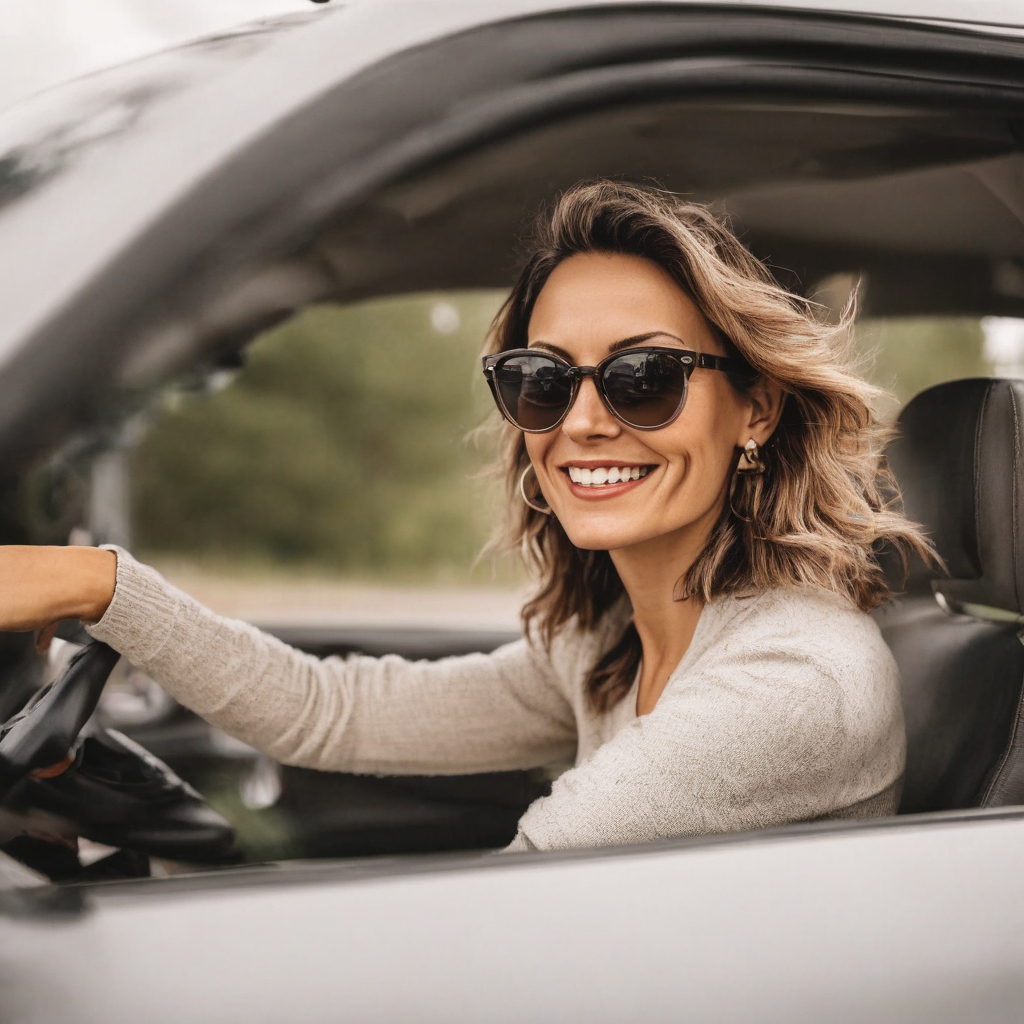

In [8]:
RESOLUTION = 1024

prompt = f"Photo of {TRIGGER} driving a car"
neg = "cartoon, anime, illustration, blurry, low quality, bad proportions, deformation watermark, logo, text"

print("Image generation started!")
image = pipe(prompt, negative_prompt=neg, num_inference_steps=30, guidance_scale=7.5, height=RESOLUTION, width=RESOLUTION).images[0]

image.save("sample_lora_output.png")
print("Saved sample_lora_output.png")
display(image)